First we import some library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings

<function _py_warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

Load Dataset

In [ ]:
df=pd.read_csv('heart.csv')

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

Visulizing the numerical columns using histplot this step we find data flow and outliers

In [ ]:
num=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']

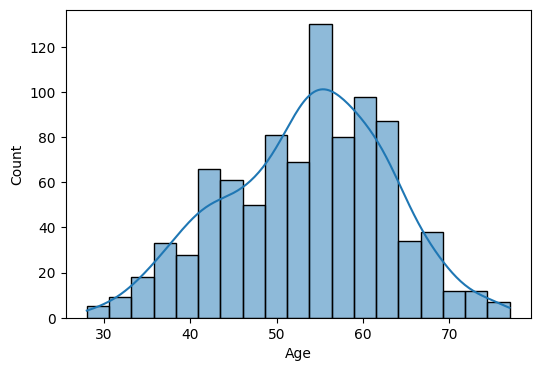

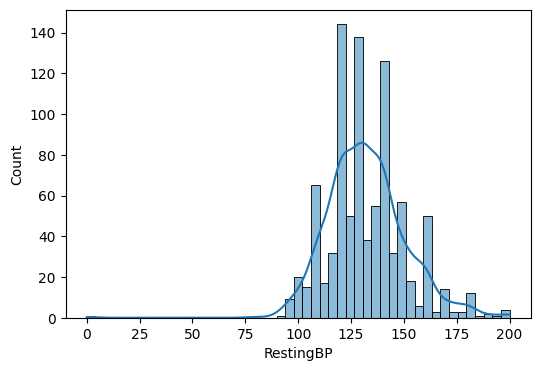

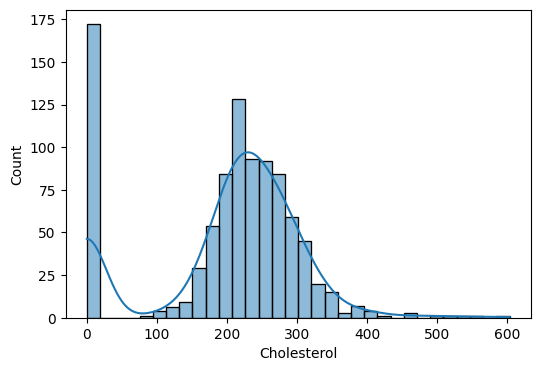

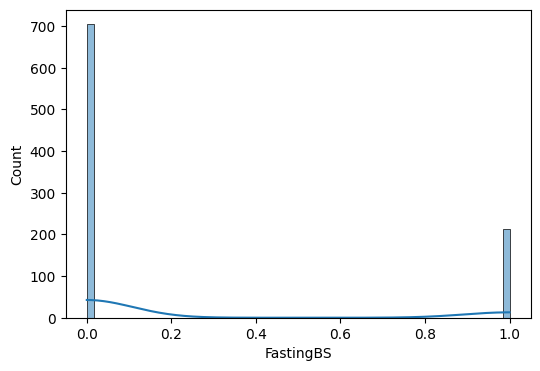

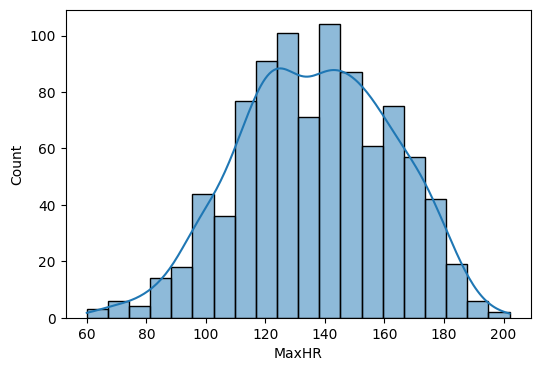

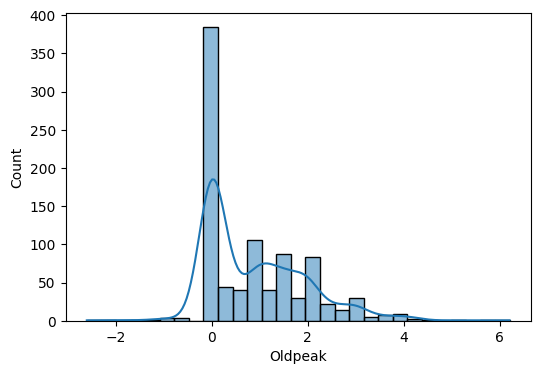

In [ ]:
for i in num:
    plt.figure(figsize=(6,4))
    sns.histplot(x=df[i],kde=True)

Used Boxplot find the outliers

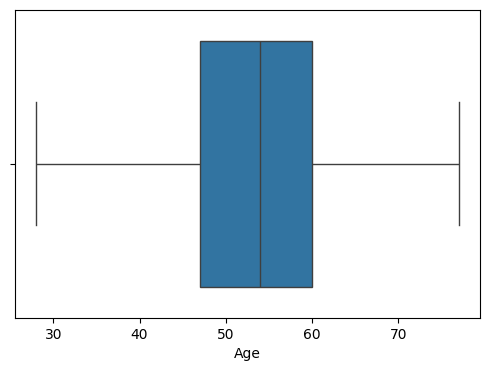

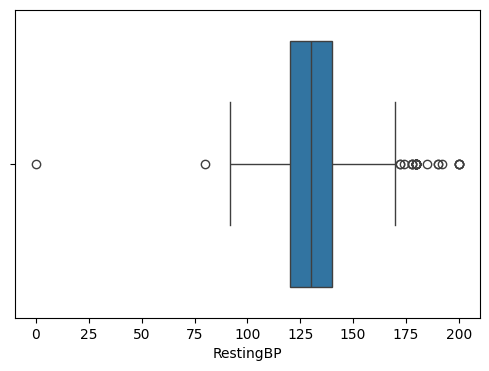

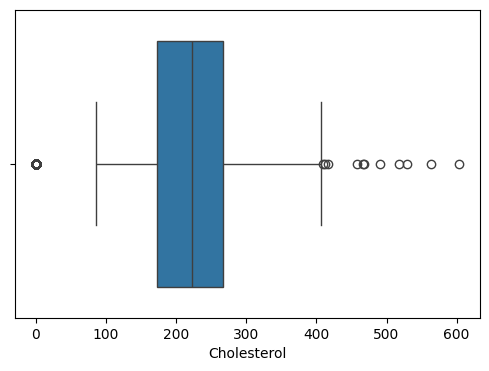

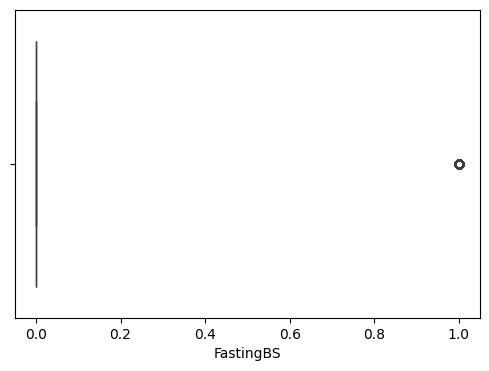

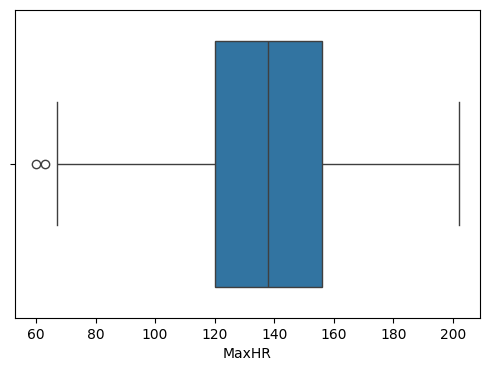

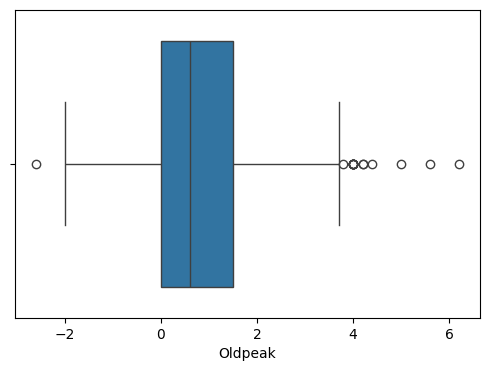

In [ ]:
for i in num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])

Data Cleaning and Preprocessing

In [ ]:
clean_df=df.copy()

In [ ]:
mean=clean_df['RestingBP'].mean()

In [ ]:
Q1=df['RestingBP'].quantile(0.25)
Q3=df['RestingBP'].quantile(0.75)

In [ ]:
IQR=Q3-Q1

In [ ]:
upper=Q3+(1.5*IQR)
lower=Q1-(1.5*IQR)

In [ ]:
print(upper,lower)

170.0 90.0


In [ ]:
clean_df.query('RestingBP >90 & RestingBP <170' ,inplace=True)

<Axes: xlabel='RestingBP'>

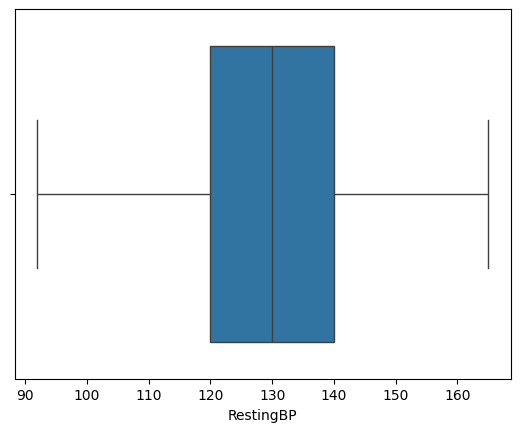

In [ ]:
sns.boxplot(x=clean_df['RestingBP'])

In [ ]:
clean_df['Cholesterol'].mean()

np.float64(198.64497716894977)

In [ ]:
Q1=df['Cholesterol'].quantile(0.25)
Q3=df['Cholesterol'].quantile(0.75)
IQR=Q3-Q1
upper=Q3+(1.5*IQR)
lower=Q1-(1.5*IQR)
print(upper,lower)

407.625 32.625


In [ ]:
clean_df.query('Cholesterol>96& Cholesterol <407 ',inplace=True)

<Axes: xlabel='Cholesterol'>

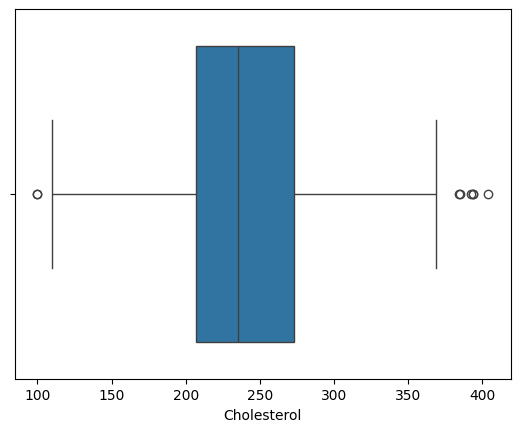

In [ ]:
sns.boxplot(x=clean_df['Cholesterol'])

In [ ]:
clean_df['Cholesterol'].mean()

np.float64(239.92296718972895)

In [ ]:
clean_df['FastingBS'].value_counts()

FastingBS
0    589
1    112
Name: count, dtype: int64

In [ ]:
clean_df.shape

(701, 12)

In [ ]:
Q1=df['MaxHR'].quantile(0.25)
Q3=df['MaxHR'].quantile(0.75)
IQR=Q3-Q1
upper=Q3+(1.5*IQR)
lower=Q1-(1.5*IQR)
print(upper,lower)

210.0 66.0


<Axes: xlabel='MaxHR', ylabel='Count'>

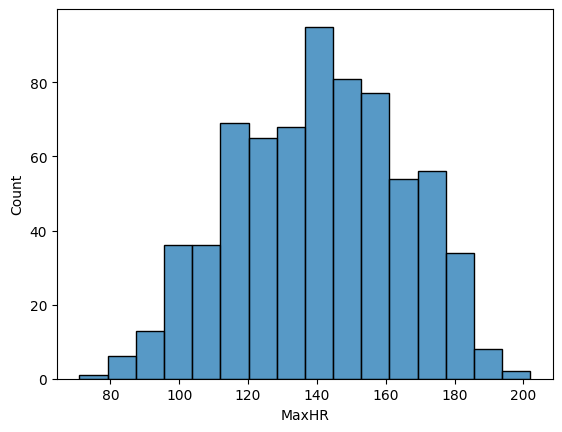

In [ ]:
sns.histplot(x=clean_df['MaxHR'])

In [ ]:
clean_df.query('MaxHR >210 & MaxHR<80')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [ ]:
Q1=df['Oldpeak'].quantile(0.25)
Q3=df['Oldpeak'].quantile(0.75)
IQR=Q3-Q1
upper=Q3+(1.5*IQR)
lower=Q1-(1.5*IQR)
print(upper,lower)

3.75 -2.25


In [ ]:
clean_df.query('Oldpeak <4 & Oldpeak >-1',inplace=True)

<Axes: xlabel='Oldpeak', ylabel='Count'>

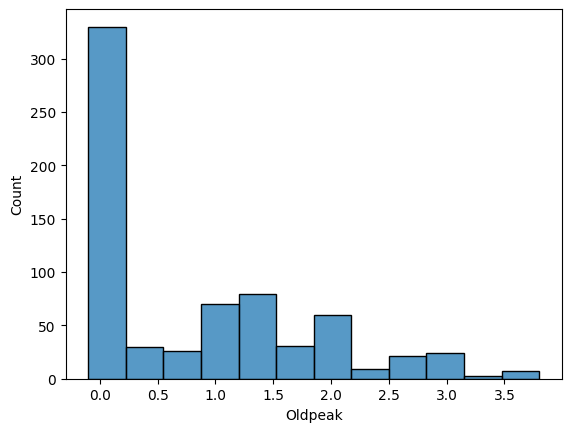

In [ ]:
sns.histplot(x=clean_df['Oldpeak'])

In [ ]:
clean_df['HeartDisease'].value_counts()

HeartDisease
0    373
1    317
Name: count, dtype: int64

In [ ]:
clean_df.query('HeartDisease !=1 & HeartDisease!=0')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


Find Relationship Numercial Columns

In [ ]:
rel=[]
for col in num:
    corr=clean_df[col].corr(clean_df['HeartDisease'])
    rel.append(corr)
rel    

[np.float64(0.29416891755910296),
 np.float64(0.15402600889173126),
 np.float64(0.09124237766256488),
 np.float64(0.15833928143241852),
 np.float64(-0.3894040165566283),
 np.float64(0.4977004124093862)]

In [ ]:
cat = ['Sex','ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [ ]:
clean_df['ChestPainType'].value_counts()

ChestPainType
ASY    331
NAP    163
ATA    159
TA      37
Name: count, dtype: int64

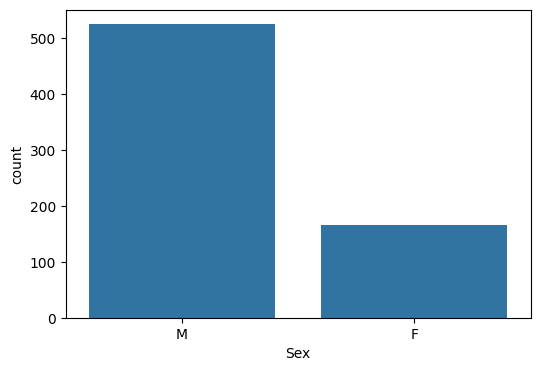

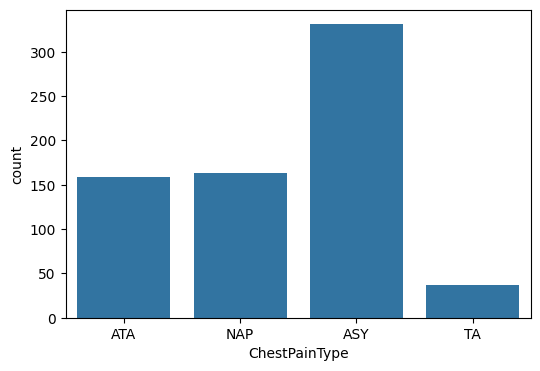

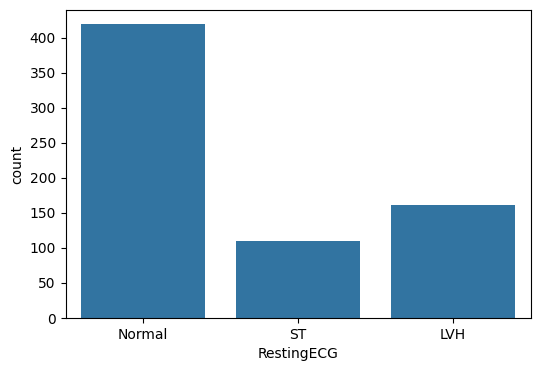

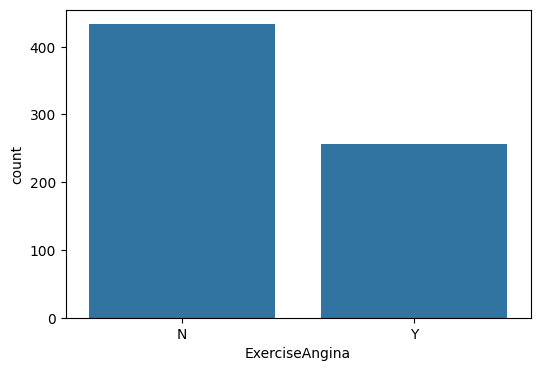

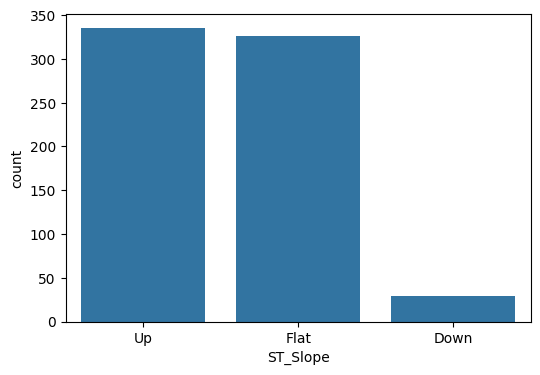

In [ ]:
for col in cat:
    plt.figure(figsize=(6,4))
    sns.countplot(x=clean_df[col])

Find Relationship categorical col to heatdisease col using chi2_square test

In [ ]:

from scipy.stats import chi2_contingency

def cramers_v(chi2, table):
    n = table.sum().sum()
    r, c = table.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

def categorical_relationship(df, cat_cols, target):
    results = []

    for col in cat_cols:
        table = pd.crosstab(df[col], df[target])

        # skip invalid columns
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue

        chi2, p, dof, _ = chi2_contingency(table)
        v = cramers_v(chi2, table)

        results.append({
            "feature": col,
            "chi2": chi2,
            "p_value": p,
            "cramers_v": v
        })

    result_df = pd.DataFrame(results)

    # sort by strength (best relationship first)
    return result_df.sort_values(by="cramers_v", ascending=False)

# -------------------------
# Example
# -------------------------


result = categorical_relationship(clean_df, cat, 'HeartDisease')

print(result)

          feature        chi2       p_value  cramers_v
4        ST_Slope  288.210862  2.604992e-63   0.646295
3  ExerciseAngina  204.161325  2.580971e-46   0.543954
1   ChestPainType  197.490444  1.470248e-42   0.534993
0             Sex   64.001931  1.242973e-15   0.304559
2      RestingECG   11.769118  2.782073e-03   0.130601


In [ ]:
# if you can find the correlation between two columns
# 1.numerical to numerical -> df.corr(col)
# 2.categorical to numerical -> anova test
# 3.categorical to categorical -> chi-square test 
# 4.numerical to categorical ->anova test
# 5.categorical to binary ->chi-square test

In [ ]:
clean_df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

Relationship only numarical col

<Axes: >

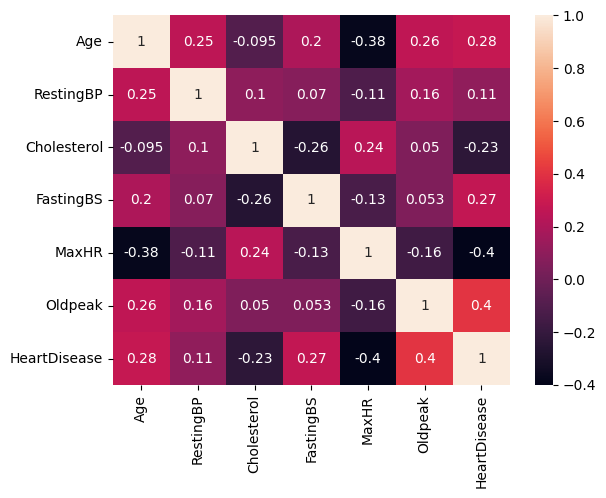

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Drop columns no-relationship

In [ ]:
clean_df.drop(['RestingBP','Cholesterol','FastingBS','RestingECG'],axis=1,inplace=True)

In [ ]:
clean_df.head()

,Age,Sex,ChestPainType,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,172,N,0.0,Up,0
1,49,F,NAP,156,N,1.0,Flat,1
2,37,M,ATA,98,N,0.0,Up,0
3,48,F,ASY,108,Y,1.5,Flat,1
4,54,M,NAP,122,N,0.0,Up,0


In [ ]:
import pickle
pickle.dump(clean_df,open('data.pkl','wb'))
clean_df.to_csv('hearts.csv')

Used(Feature Scaler) StandardScaler and LabelEncoder convert minimize and binary data

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cols=['Sex','ChestPainType','ExerciseAngina','ST_Slope']
for col in cols:
    clean_df[col]=le.fit_transform(clean_df[col])


In [ ]:
clean_df=clean_df.astype(int)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scol=['Age','MaxHR']
clean_df[scol]=scaler.fit_transform(clean_df[scol])

Spliting model for training and testion

In [ ]:
from sklearn.model_selection import train_test_split
x=clean_df.drop('HeartDisease',axis=1)
y=clean_df['HeartDisease']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=20)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier

Import GridSearchCV for find the best parameters

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01, 0.1, 0.5, 1]}
grid = GridSearchCV(BernoulliNB(), params, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'alpha': 0.01}


In [ ]:
params = {'kernel' : ['linear', 'rbf', 'poly'],
          'C' : [0.1, 1, 10, 100],
          'gamma' : ['scale']  }
grid = GridSearchCV(SVC(), params, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'C': 1, 'gamma': 'scale', 'kernel': 'poly'}


In [ ]:

params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), params, cv=3)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


c:\Users\yadav\Desktop\python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yadav\Desktop\python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\yadav\Desktop\python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

Fit model

In [ ]:
# model=model = BernoulliNB(
#     alpha=0.5,        # smoothing
#     binarize=1.4 ,  # threshold for binary features
#     fit_prior=True   # learn class probabilities
# )
# model = SVC(
#     kernel='linear',
#     C=0.1,
#     gamma='scale'
# )
model = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='liblinear',
    class_weight='balanced'
)
model.fit(x_train,y_train)

c:\Users\yadav\Desktop\python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Model Prediction

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,roc_auc_score,f1_score
print('accurrecy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accurrecy 0.8208955223880597
f1 score 0.7945205479452054


Another way you use Esembal Methods

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=100)
model.fit(x_train, y_train)

print(model.score(x_test, y_test))

0.8253731343283582


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(x_train, y_train)

print(model.score(x_test, y_test))

0.8194029850746268


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier())
]

model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

model.fit(x_train, y_train)
print(model.score(x_test, y_test))

0.7701492537313432


In [ ]:
clean_df.head()

,Age,Sex,ChestPainType,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.327723,1,1,1.280770,0,0,2,0
1,-0.379131,0,2,0.624300,0,1,1,1
2,-1.643920,1,1,-1.755402,0,0,2,0
3,-0.484530,0,0,-1.345109,1,1,1,1
4,0.147864,1,2,-0.770698,0,0,2,0
